# EDA — Elliptic Bitcoin Dataset

Semana 1-2. Antes de correr esto: ejecuta `python src/graph/build_graph.py` desde la raíz del repo (requiere los 3 CSV crudos en `data/raw/`, ver `data/README.md`).

Objetivos de este notebook:
1. Distribución de clases por time step (para justificar el split temporal y la métrica AUC-PR).
2. Estadísticas básicas del grafo (grado de entrada/salida, componentes conexas).
3. Primeras hipótesis sobre qué features locales/agregadas separan mejor lícito de ilícito (input para la Semana 3).

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

PROCESSED = Path.cwd().parent / "data" / "processed"
nodes = pd.read_parquet(PROCESSED / "nodes.parquet")
edges = pd.read_parquet(PROCESSED / "edges.parquet")
nodes.shape, edges.shape

((203769, 168), (234355, 2))

## 1. Clases por time step

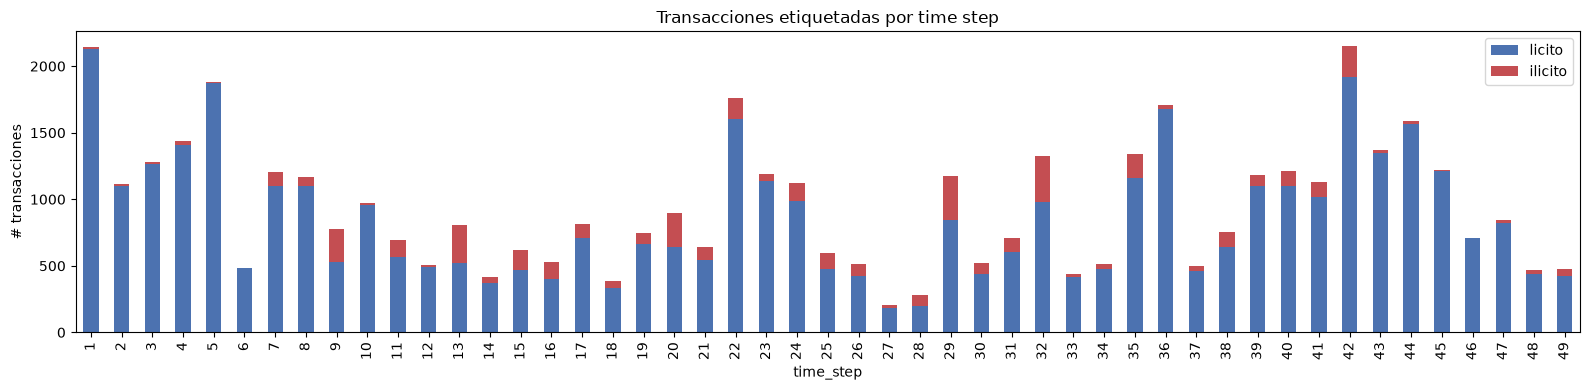

% ilícito sobre etiquetadas: 9.76 %


In [6]:
class_by_step = (
    nodes[nodes["label"] != -1]
    .groupby(["time_step", "label"])
    .size()
    .unstack(fill_value=0)
)
class_by_step.columns = ["licito", "ilicito"]
class_by_step.plot(kind="bar", stacked=True, figsize=(16, 4), color=["#4C72B0", "#C44E52"])
plt.title("Transacciones etiquetadas por time step")
plt.xlabel("time_step")
plt.ylabel("# transacciones")
plt.tight_layout()
plt.show()

print("% ilícito sobre etiquetadas:", round(100 * (nodes["label"] == 1).sum() / (nodes["label"] != -1).sum(), 2), "%")

## 2. Estadísticas del grafo

In [7]:
g = nx.from_pandas_edgelist(edges, source="src", target="dst", create_using=nx.DiGraph)
print("Nodos:", g.number_of_nodes(), "| Aristas:", g.number_of_edges())

in_deg = pd.Series(dict(g.in_degree()))
out_deg = pd.Series(dict(g.out_degree()))
print("Grado de entrada — media:", in_deg.mean().round(3), "| máx:", in_deg.max())
print("Grado de salida — media:", out_deg.mean().round(3), "| máx:", out_deg.max())

n_components = nx.number_weakly_connected_components(g)
print("Componentes débilmente conexas:", n_components)

Nodos: 203769 | Aristas: 234355
Grado de entrada — media: 1.15 | máx: 284
Grado de salida — media: 1.15 | máx: 472
Componentes débilmente conexas: 49


## 3. Separabilidad preliminar de features (local vs. agregada)

In [8]:
labeled = nodes[nodes["label"] != -1].copy()
feature_cols = [c for c in nodes.columns if c.startswith("local_") or c.startswith("agg_")]

# Diferencia de medias estandarizada (proxy rápido de separabilidad, no es el análisis final)
means_illicit = labeled[labeled["label"] == 1][feature_cols].mean()
means_licit = labeled[labeled["label"] == 0][feature_cols].mean()
stds = labeled[feature_cols].std().replace(0, 1e-9)
separability = ((means_illicit - means_licit).abs() / stds).sort_values(ascending=False)
separability.head(15)

local_52    0.881009
local_88    0.766980
local_54    0.765351
local_89    0.745635
agg_48      0.646712
agg_56      0.630865
local_90    0.626051
local_51    0.578865
agg_60      0.515408
local_53    0.478878
agg_20      0.463753
agg_54      0.457831
agg_62      0.455465
local_82    0.415920
local_84    0.401223
dtype: float64

## Próximos pasos (Semana 3)

- Confirmar con estas ~15 features de mayor separabilidad si tienen sentido combinadas con features de grafo (grado, centralidad, tamaño de componente).
- Diseñar el split temporal definitivo (train ≤34, val 35-42, test >42) ya construido en `build_pyg_data`.
- Documentar en el README qué decisiones de feature engineering se tomaron y por qué (esto es parte de lo que un reclutador va a leer).

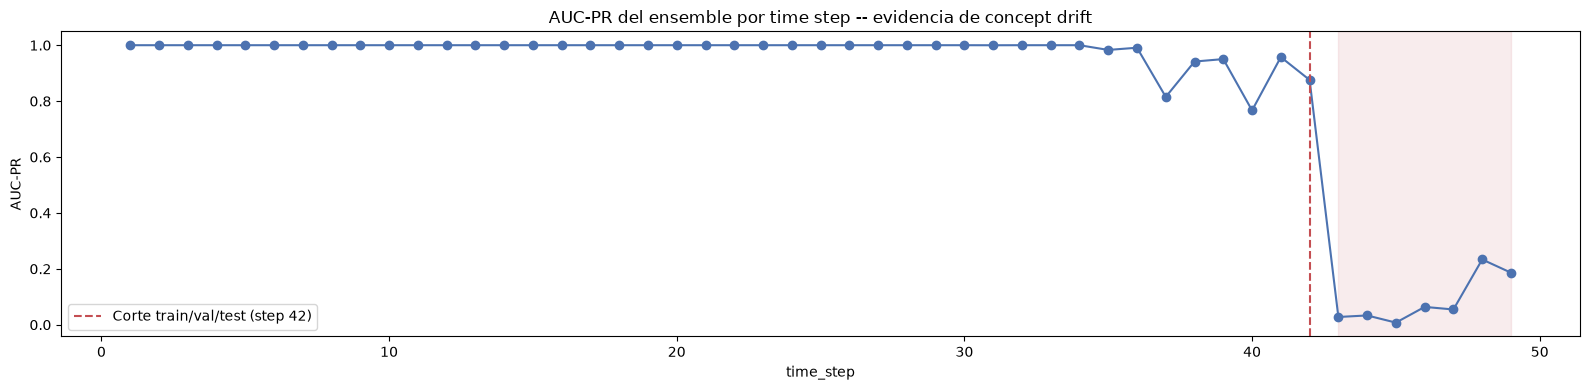

AUC-PR medio antes del corte (train/val): 0.9829
AUC-PR medio después del corte (test): 0.0867


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import average_precision_score

nodes_feat = pd.read_parquet("../data/processed/nodes_with_graph_features.parquet")
scores = pd.read_parquet("../models/ensemble_scores.parquet")

# AUC-PR por time step para el ensemble, sobre nodos etiquetados
auc_by_step = []
for step in sorted(scores["time_step"].unique()):
    sub = scores[scores["time_step"] == step]
    if sub["label"].nunique() < 2:
        continue
    auc_by_step.append({"time_step": step, "auc_pr": average_precision_score(sub["label"], sub["ensemble_proba"])})

auc_df = pd.DataFrame(auc_by_step)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(auc_df["time_step"], auc_df["auc_pr"], marker="o", color="#4C72B0")
ax.axvline(x=42, color="#C44E52", linestyle="--", label="Corte train/val/test (step 42)")
ax.axvspan(43, auc_df["time_step"].max(), alpha=0.1, color="#C44E52")
ax.set_title("AUC-PR del ensemble por time step -- evidencia de concept drift")
ax.set_xlabel("time_step")
ax.set_ylabel("AUC-PR")
ax.legend()
plt.tight_layout()
plt.savefig("../models/auc_pr_by_timestep.png", dpi=150)
plt.show()

print("AUC-PR medio antes del corte (train/val):", round(auc_df[auc_df['time_step'] <= 42]['auc_pr'].mean(), 4))
print("AUC-PR medio después del corte (test):", round(auc_df[auc_df['time_step'] > 42]['auc_pr'].mean(), 4))